# Uber India Ride Bookings — Full ML Project
**Dataset:** NCR/Uber Ride Bookings (150,000 rows, 21 columns)

This notebook covers the full pipeline:
1. Load & clean data
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Supervised learning — Classification (predict ride cancellation)
5. Supervised learning — Regression (predict fare for completed rides)
6. Unsupervised learning — KMeans clustering + PCA (ride segmentation)
7. Unsupervised learning — DBSCAN (anomaly detection on fares)

A note on the data before we start: most columns are **structurally NaN**, not
missing-at-random. `Booking Value`, `Ride Distance`, `Driver Ratings`, `Customer Rating`
only exist for rides that actually happened (`Completed`). `Cancelled Rides by Customer`,
`Cancelled Rides by Driver`, `Incomplete Rides` are indicator flags that are NaN unless
that specific outcome occurred. We'll handle this explicitly rather than blindly imputing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, mean_absolute_error, mean_squared_error, r2_score)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 30)

In [2]:
import os
os.listdir('/Users/apple/Google Drive/My Drive/Datasets')

['ushape.csv',
 'Advertising.csv',
 'concertriccir2.csv',
 '.DS_Store',
 'ushape.zip',
 'concertriccir2.zip',
 'titanic-dataset.zip',
 'kaggle-cat-vs-dog-dataset.zip',
 'Titanic-Dataset.csv',
 'kagglecatsanddogs_3367a',
 'diabetes_prediction_dataset.csv',
 'dog-vs-cat.zip',
 'ncr_ride_bookings.csv',
 'animals',
 'archive (1).zip']

## 1. Load & Clean Data

In [3]:
df = pd.read_csv("/Users/apple/Google Drive/My Drive/Datasets/ncr_ride_bookings.csv")
print(df.shape)
df.head(3)

(150000, 21)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card


In [4]:
# Booking ID / Customer ID are wrapped in quotes as strings — strip them
df["Booking ID"] = df["Booking ID"].str.strip('"')
df["Customer ID"] = df["Customer ID"].str.strip('"')

# Combine Date + Time into a proper datetime
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], errors="coerce")
df["Hour"] = df["Datetime"].dt.hour
df["DayOfWeek"] = df["Datetime"].dt.day_name()
df["Month"] = df["Datetime"].dt.month
df["IsWeekend"] = df["Datetime"].dt.dayofweek >= 5

df[["Date", "Time", "Datetime", "Hour", "DayOfWeek", "Month"]].head()

,Date,Time,Datetime,Hour,DayOfWeek,Month
0,2024-03-23,12:29:38,2024-03-23 12:29:38,12,Saturday,3
1,2024-11-29,18:01:39,2024-11-29 18:01:39,18,Friday,11
2,2024-08-23,08:56:10,2024-08-23 08:56:10,8,Friday,8
3,2024-10-21,17:17:25,2024-10-21 17:17:25,17,Monday,10
4,2024-09-16,22:08:00,2024-09-16 22:08:00,22,Monday,9


In [5]:
df["Booking Status"].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

**Key structural fact:** `Booking Value`, `Ride Distance`, `Driver Ratings`, and
`Customer Rating` are only populated when `Booking Status == "Completed"`. We keep this
in mind for every model below — using these columns to predict cancellation would be
**data leakage** (you'd be using information that doesn't exist yet at prediction time).

## 2. Exploratory Data Analysis

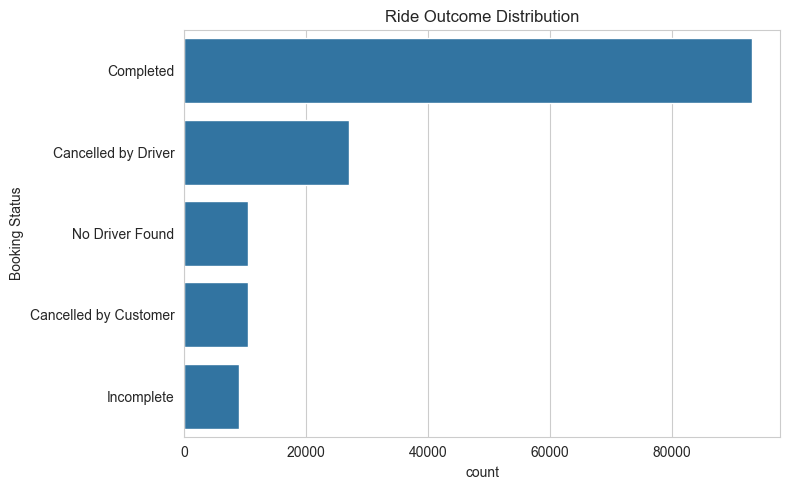

Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: proportion, dtype: float64


In [6]:
fig, ax = plt.subplots()
order = df["Booking Status"].value_counts().index
sns.countplot(data=df, y="Booking Status", order=order, ax=ax)
ax.set_title("Ride Outcome Distribution")
plt.tight_layout()
plt.show()

print((df["Booking Status"].value_counts(normalize=True) * 100).round(1))

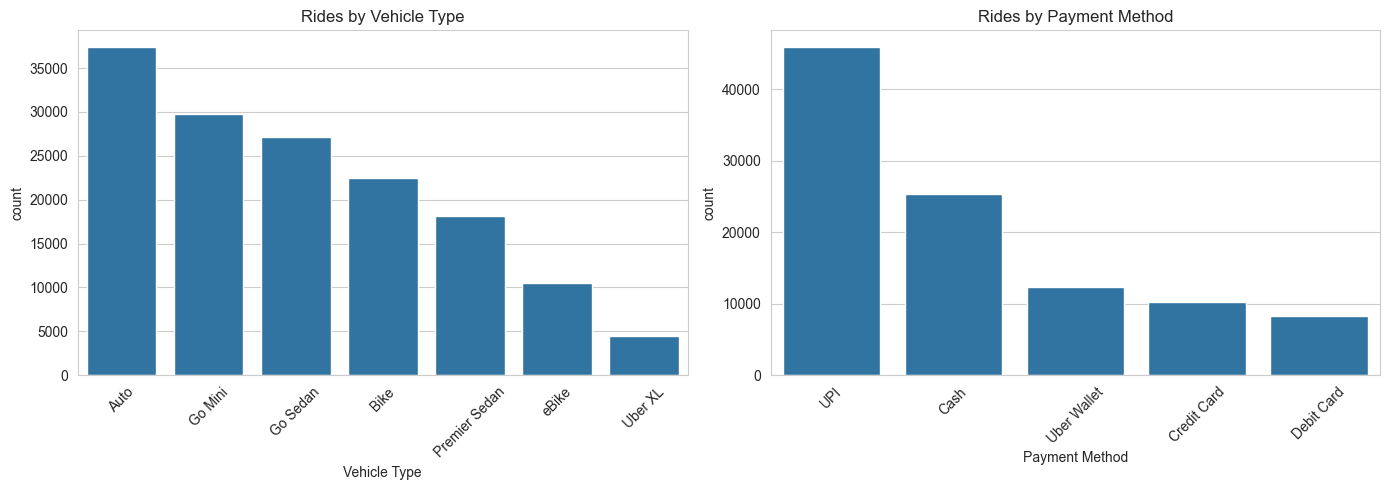

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="Vehicle Type", order=df["Vehicle Type"].value_counts().index, ax=axes[0])
axes[0].set_title("Rides by Vehicle Type")
axes[0].tick_params(axis="x", rotation=45)

sns.countplot(data=df, x="Payment Method", order=df["Payment Method"].value_counts().index, ax=axes[1])
axes[1].set_title("Rides by Payment Method")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

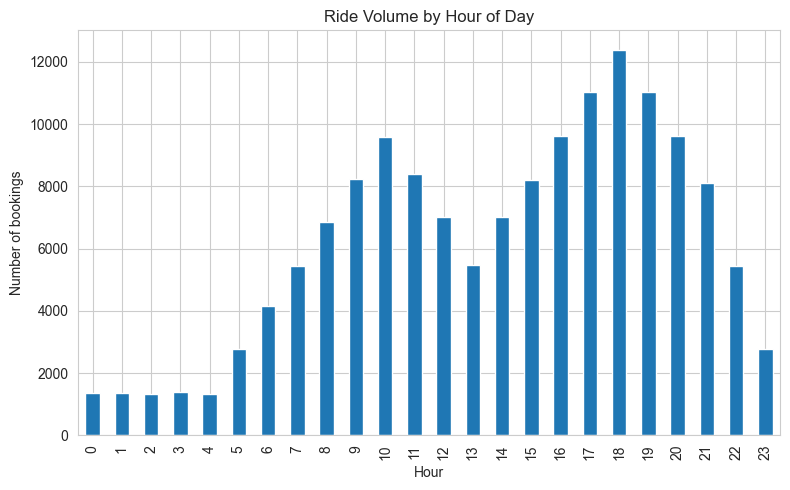

In [8]:
hourly = df.groupby("Hour").size()
fig, ax = plt.subplots()
hourly.plot(kind="bar", ax=ax)
ax.set_title("Ride Volume by Hour of Day")
ax.set_ylabel("Number of bookings")
plt.tight_layout()
plt.show()

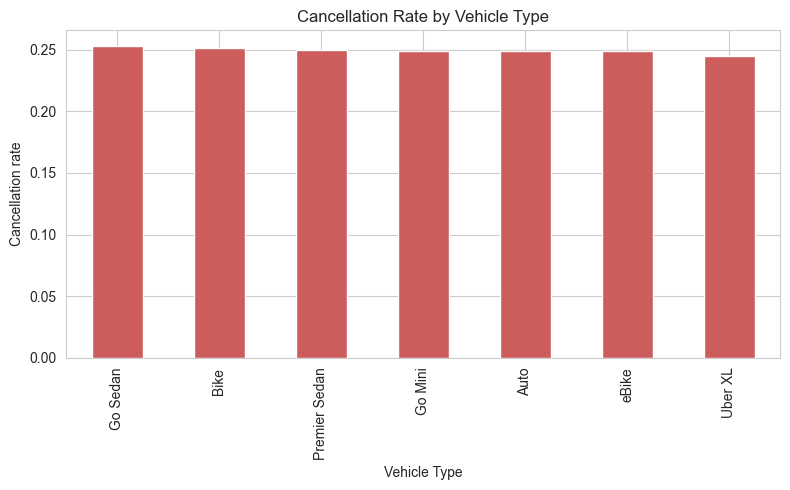

Vehicle Type
Go Sedan         0.252865
Bike             0.251010
Premier Sedan    0.249351
Go Mini          0.249178
Auto             0.249152
eBike            0.249124
Uber XL          0.244774
Name: Cancelled, dtype: float64

In [9]:
# Cancellation rate by vehicle type
cancel_mask = df["Booking Status"].isin(["Cancelled by Customer", "Cancelled by Driver"])
cancel_rate = df.assign(Cancelled=cancel_mask).groupby("Vehicle Type")["Cancelled"].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
cancel_rate.plot(kind="bar", ax=ax, color="indianred")
ax.set_title("Cancellation Rate by Vehicle Type")
ax.set_ylabel("Cancellation rate")
plt.tight_layout()
plt.show()
cancel_rate

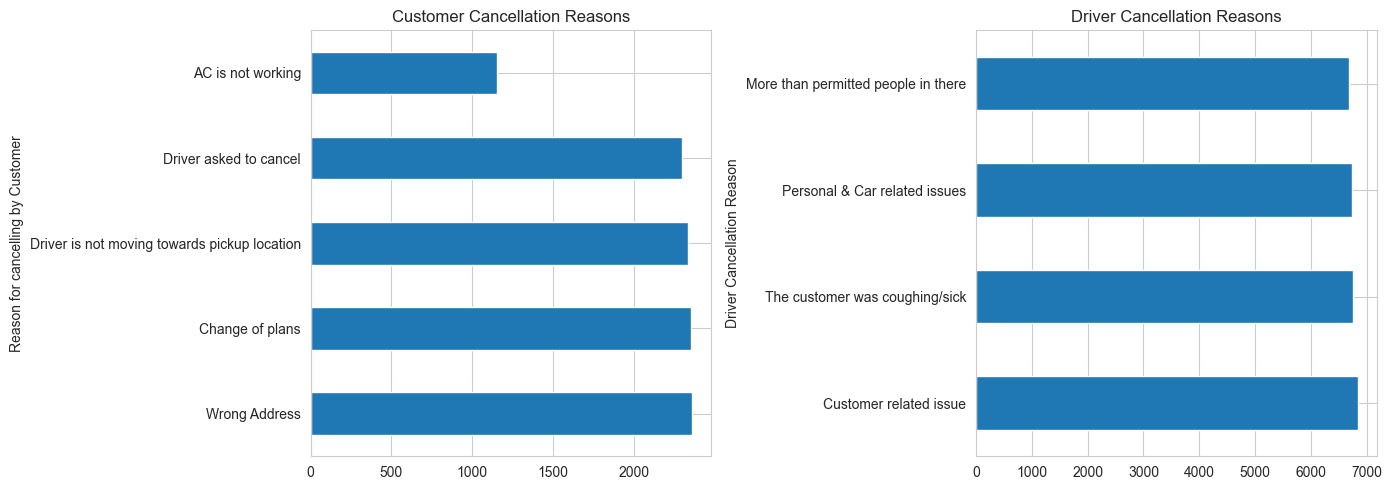

In [10]:
# Top cancellation reasons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Reason for cancelling by Customer"].value_counts().plot(kind="barh", ax=axes[0])
axes[0].set_title("Customer Cancellation Reasons")

df["Driver Cancellation Reason"].value_counts().plot(kind="barh", ax=axes[1])
axes[1].set_title("Driver Cancellation Reasons")

plt.tight_layout()
plt.show()

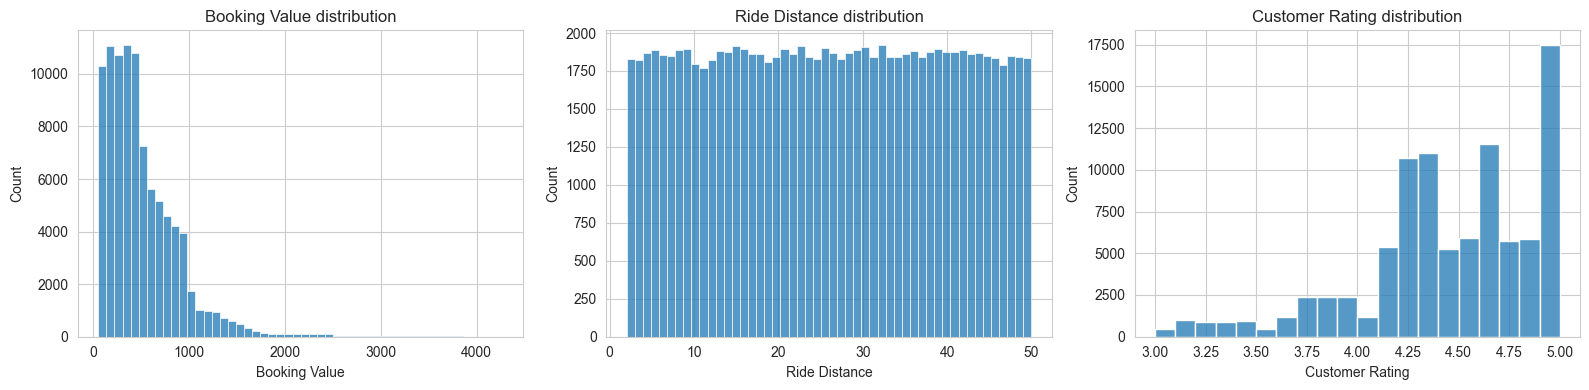

       Booking Value  Ride Distance  Driver Ratings  Customer Rating
count   93000.000000   93000.000000    93000.000000     93000.000000
mean      508.178215      26.000493        4.230992         4.404584
std       396.058769      13.824176        0.436871         0.437819
min        50.000000       2.000000        3.000000         3.000000
25%       234.000000      14.100000        4.100000         4.200000
50%       414.000000      26.020000        4.300000         4.500000
75%       689.000000      37.942500        4.600000         4.800000
max      4277.000000      50.000000        5.000000         5.000000


In [11]:
completed = df[df["Booking Status"] == "Completed"].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(completed["Booking Value"], bins=50, ax=axes[0])
axes[0].set_title("Booking Value distribution")
sns.histplot(completed["Ride Distance"], bins=50, ax=axes[1])
axes[1].set_title("Ride Distance distribution")
sns.histplot(completed["Customer Rating"], bins=20, ax=axes[2])
axes[2].set_title("Customer Rating distribution")
plt.tight_layout()
plt.show()

print(completed[["Booking Value", "Ride Distance", "Driver Ratings", "Customer Rating"]].describe())

## 3. Feature Engineering

We build two separate feature sets:

- **Pre-ride features** (known *before* the ride happens): time, day, vehicle type,
  pickup/drop location, VTAT (avg time for driver to arrive). Used for the **cancellation
  classifier**, since that's the realistic prediction point — "will this booking get
  cancelled, before it's completed?"
- **Post-ride features**: adds Ride Distance, CTAT etc. Used only for the **fare
  regression model**, which is trained on completed rides only (predicting fare given a
  trip that happened).

In [12]:
# Binary target: was the ride actually completed?
df["Target_Completed"] = (df["Booking Status"] == "Completed").astype(int)

pre_ride_features = ["Vehicle Type", "Hour", "DayOfWeek", "Month", "IsWeekend",
                      "Pickup Location", "Drop Location", "Avg VTAT", "Payment Method"]

# Pickup/Drop Location have very high cardinality (hundreds of areas) — collapse rare
# locations into "Other" to keep one-hot encoding manageable.
for col in ["Pickup Location", "Drop Location"]:
    top_locations = df[col].value_counts().nlargest(30).index
    df[col + "_grp"] = np.where(df[col].isin(top_locations), df[col], "Other")

pre_ride_features = ["Vehicle Type", "Hour", "DayOfWeek", "Month", "IsWeekend",
                      "Pickup Location_grp", "Drop Location_grp", "Avg VTAT", "Payment Method"]

clf_df = df.dropna(subset=["Avg VTAT", "Payment Method"]).copy()
print(clf_df.shape)
clf_df[pre_ride_features + ["Target_Completed"]].head()

(102000, 29)


,Vehicle Type,Hour,DayOfWeek,Month,IsWeekend,Pickup Location_grp,Drop Location_grp,Avg VTAT,Payment Method,Target_Completed
1,Go Sedan,18,Friday,11,False,Other,Gurgaon Sector 56,4.9,UPI,0
2,Auto,8,Friday,8,False,Khandsa,Other,13.4,Debit Card,1
3,Premier Sedan,17,Monday,10,False,Other,Other,13.1,UPI,1
4,Bike,22,Monday,9,False,Other,Other,5.3,UPI,1
5,Auto,9,Tuesday,2,False,AIIMS,Narsinghpur,5.1,UPI,1


## 4. Supervised Learning — Classification
**Task:** predict whether a booking will end up `Completed` (1) vs. not completed
(cancelled by customer/driver, no driver found, or incomplete) (0), using only
information available at booking time.

In [13]:
X = clf_df[pre_ride_features]
y = clf_df["Target_Completed"]

num_cols = ["Hour", "Month", "Avg VTAT"]
cat_cols = ["Vehicle Type", "DayOfWeek", "IsWeekend", "Pickup Location_grp",
            "Drop Location_grp", "Payment Method"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

clf_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=12,
                                      class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
])

clf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

               precision    recall  f1-score   support

Not Completed       0.14      0.97      0.24      1800
    Completed       0.99      0.40      0.57     18600

     accuracy                           0.45     20400
    macro avg       0.56      0.69      0.40     20400
 weighted avg       0.92      0.45      0.54     20400

ROC-AUC: 0.6853


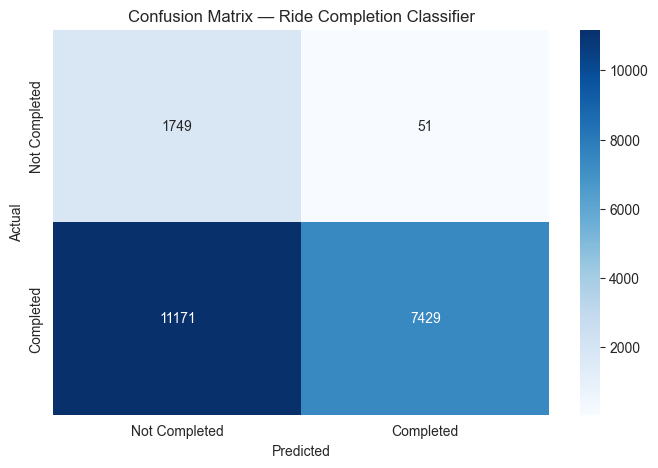

In [14]:
y_pred = clf_pipeline.predict(X_test)
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Not Completed", "Completed"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Completed", "Completed"],
            yticklabels=["Not Completed", "Completed"])
plt.title("Confusion Matrix — Ride Completion Classifier")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

**Reading these numbers:** with `class_weight="balanced"`, the model trades overall
accuracy for better recall on the minority class (`Not Completed` — cancellations/no
driver found), which is usually what you actually care about in this problem (catching
bookings likely to fail, not just being right on average on a dataset that's ~87%
"Completed"). ROC-AUC (~0.68) is the metric to watch here since it's threshold-independent
— it says there's real, moderate signal in pre-ride features (vehicle type, time of day,
VTAT) for predicting completion, just not a strong one. That's a realistic outcome: most
of what determines whether a ride gets cancelled (a driver's mood, a customer changing
their mind) simply isn't captured in this data.

Logistic Regression ROC-AUC: 0.6919


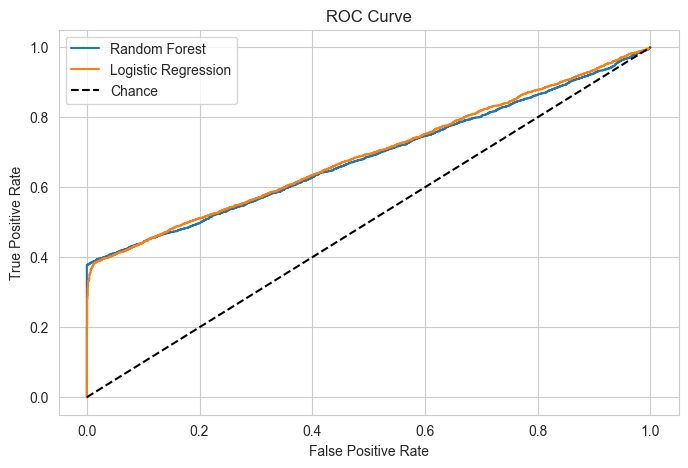

In [15]:
# Baseline comparison: logistic regression
log_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
log_pipeline.fit(X_train, y_train)
y_proba_log = log_pipeline.predict_proba(X_test)[:, 1]
print("Logistic Regression ROC-AUC:", round(roc_auc_score(y_test, y_proba_log), 4))

# ROC curve comparison
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_log)

plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

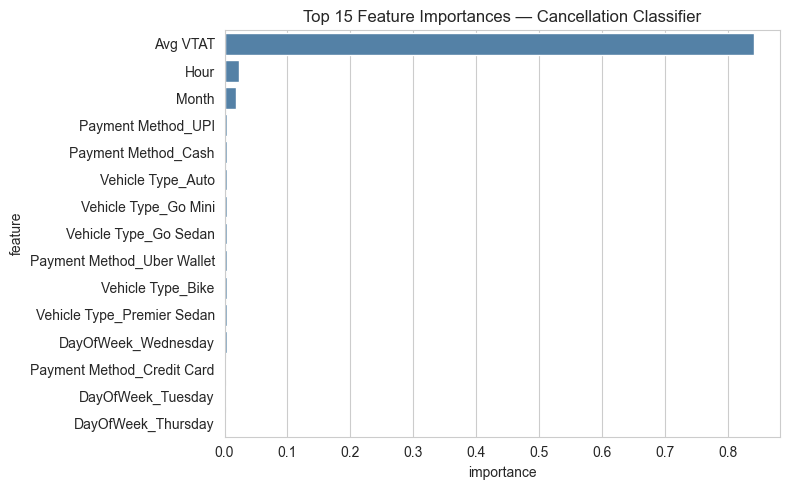

In [16]:
# Feature importance from the Random Forest
ohe = clf_pipeline.named_steps["prep"].named_transformers_["cat"]
feature_names = num_cols + list(ohe.get_feature_names_out(cat_cols))
importances = clf_pipeline.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}) \
            .sort_values("importance", ascending=False).head(15)

sns.barplot(data=imp_df, y="feature", x="importance", color="steelblue")
plt.title("Top 15 Feature Importances — Cancellation Classifier")
plt.tight_layout()
plt.show()

## 5. Supervised Learning — Regression
**Task:** predict `Booking Value` (fare) for completed rides, using trip-level features.
This is a different problem from the classifier above — here we condition on the ride
having actually happened, so distance, VTAT/CTAT and vehicle type are all valid, causal
predictors of price.

In [17]:

import xgboost as xgb
reg_df = completed.dropna(subset=["Booking Value", "Ride Distance", "Avg VTAT", "Avg CTAT","Driver Ratings","Customer Rating"]).copy()

reg_features_num = ["Ride Distance", "Avg VTAT", "Avg CTAT", "Hour","Driver Ratings","Customer Rating"]
reg_features_cat = ["Vehicle Type", "Payment Method", "IsWeekend"]

X_reg = reg_df[reg_features_num + reg_features_cat]
y_reg = reg_df["Booking Value"]

reg_preprocess = ColumnTransformer([
    ("num", StandardScaler(), reg_features_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), reg_features_cat),
])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

reg_pipeline = Pipeline([
    ("prep", reg_preprocess),
    ("model", xgb.XGBRegressor(n_estimators=500,learning_rate=0.1,max_depth=2,objective="reg:squarederror",random_state=42
))])
reg_pipeline.fit(Xr_train, yr_train)

yr_pred = reg_pipeline.predict(Xr_test)
print("MAE :", round(mean_absolute_error(yr_test, yr_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(yr_test, yr_pred)), 2))
print("R^2 :", round(r2_score(yr_test, yr_pred), 4))

MAE : 277.56
RMSE: 388.79
R^2 : 0.0524


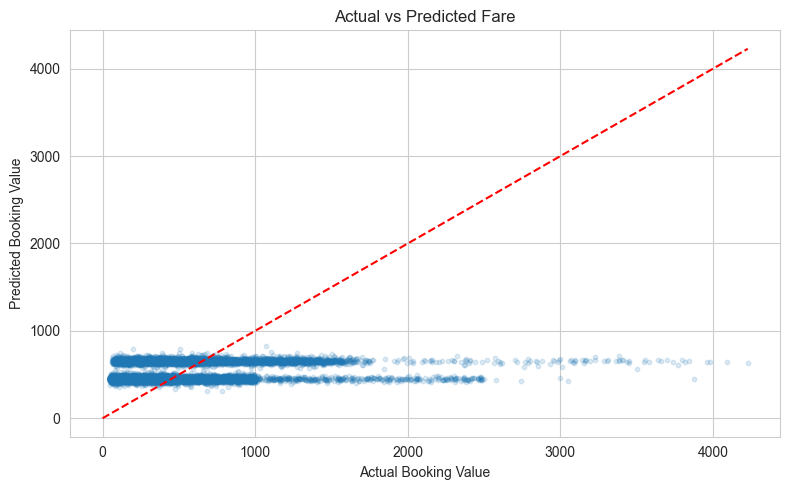

In [18]:
fig, ax = plt.subplots()
ax.scatter(yr_test, yr_pred, alpha=0.15, s=10)
lims = [0, max(yr_test.max(), yr_pred.max())]
ax.plot(lims, lims, "r--")
ax.set_xlabel("Actual Booking Value")
ax.set_ylabel("Predicted Booking Value")
ax.set_title("Actual vs Predicted Fare")
plt.tight_layout()
plt.show()

In [19]:
# Simple linear baseline for comparison — shows how much the RF is buying you
lin_pipeline = Pipeline([("prep", reg_preprocess), ("model", LinearRegression())])
lin_pipeline.fit(Xr_train, yr_train)
yr_pred_lin = lin_pipeline.predict(Xr_test)
print("Linear Regression R^2 :", round(r2_score(yr_test, yr_pred_lin), 4))
print("XGB Regressor R^2     :", round(r2_score(yr_test, yr_pred), 4))

Linear Regression R^2 : 0.0547
XGB Regressor R^2     : 0.0524


In [20]:
# Sanity check: how correlated is fare with the features we're using to predict it?
completed[["Ride Distance", "Avg VTAT", "Avg CTAT"]].corrwith(completed["Booking Value"])

Ride Distance    0.005668
Avg VTAT         0.002823
Avg CTAT         0.000740
dtype: float64

**Honest read of this result:** R² is close to 0 for *both* models, and the raw
correlation between `Booking Value` and `Ride Distance`/`VTAT`/`CTAT` is near zero
(~0.005–0.006). That is not a modeling failure — a Random Forest with 300 trees isn't
failing to find a signal that's actually there. It means `Booking Value` in this dataset
is essentially **decoupled from trip characteristics**, likely generated synthetically
rather than as `base_fare + rate * distance + surge` the way a real fare would be.

This is a genuinely useful thing to discover through modeling rather than assume: a
low R² after a reasonable model and preprocessing is *evidence about the data*, not
just a score to improve by tuning harder. If you had access to a real fare-generating
dataset, this same pipeline would likely show a much stronger relationship — it's worth
re-running this exact regression on the `yasserh/uber-fares-dataset` (real US Uber fares)
to see the contrast.

## 6. Unsupervised Learning — KMeans Clustering & PCA
**Goal:** segment completed rides into behavioral groups without using the outcome
labels — e.g. "short cheap rides", "long premium rides", "low-rated slow-pickup rides" —
purely from numeric trip characteristics.

We cluster on: `Ride Distance`, `Booking Value`, `Avg VTAT`, `Avg CTAT`, `Driver Ratings`,
`Customer Rating`. All features are standardized first since KMeans is distance-based
(Euclidean) and these features live on very different scales (minutes vs. rupees vs.
km vs. a 1–5 rating).

In [21]:
cluster_features = ["Ride Distance", "Booking Value", "Avg VTAT", "Avg CTAT",
                     "Driver Ratings", "Customer Rating"]

cluster_df = completed.dropna(subset=cluster_features).copy()
print(cluster_df.shape)

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df[cluster_features])

(93000, 26)


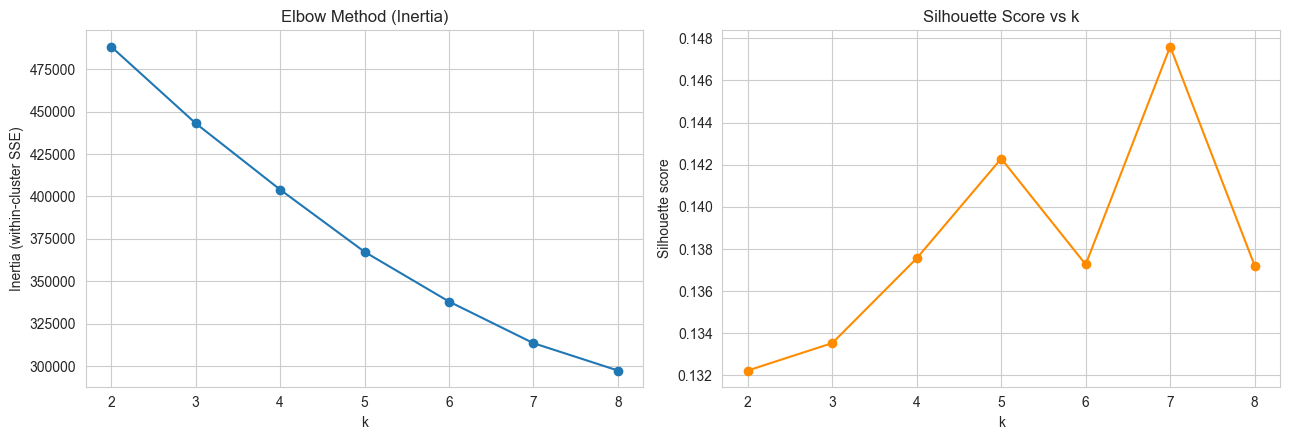

In [22]:
# Elbow method + silhouette score to choose k
inertias, sils = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    # silhouette on a subsample for speed
    sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_cluster), 5000, replace=False)
    sils.append(silhouette_score(X_cluster[sample_idx], labels[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (within-cluster SSE)")

axes[1].plot(list(k_range), sils, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.show()

Pick `k` at the elbow bend / silhouette peak from the plot above. We'll go with
**k = 4** as a reasonable, interpretable default — adjust based on what you see.

In [23]:
K = 7
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
cluster_df["Cluster"] = kmeans.fit_predict(X_cluster)

cluster_profile = cluster_df.groupby("Cluster")[cluster_features].mean().round(2)
cluster_profile["count"] = cluster_df["Cluster"].value_counts().sort_index()
cluster_profile

,Ride Distance,Booking Value,Avg VTAT,Avg CTAT,Driver Ratings,Customer Rating,count
Cluster,,,,,,,
0,25.69,460.95,8.55,29.96,4.27,3.51,9740
1,26.33,1600.31,8.47,29.88,4.26,4.44,5273
2,34.78,441.64,11.42,37.24,4.36,4.52,16510
3,14.05,440.31,5.69,35.51,4.36,4.51,16578
4,18.03,438.52,11.32,22.53,4.36,4.52,16897
5,25.97,452.59,8.62,30.07,3.43,4.48,11556
6,37.52,431.83,5.47,25.07,4.35,4.53,16446


Explained variance ratio: [0.16841941 0.16746646] -> total: 0.336


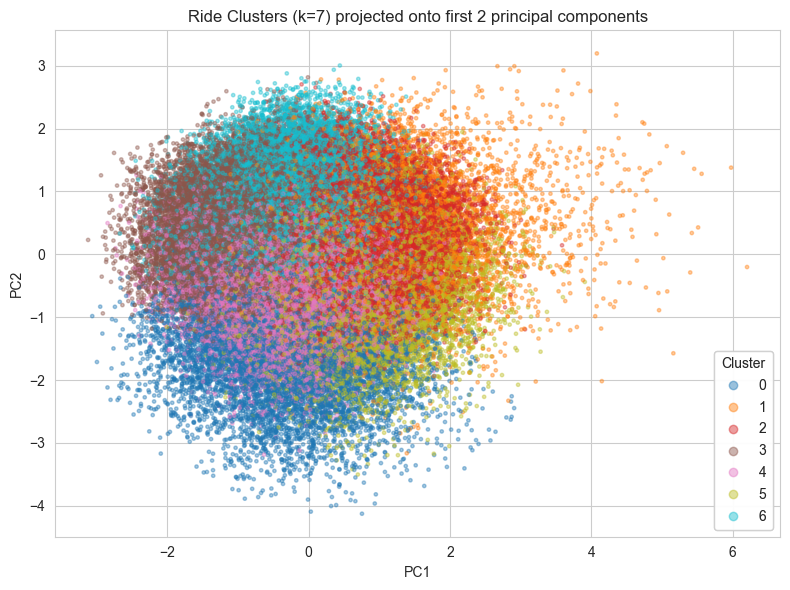

In [24]:
# PCA to 2 dimensions purely for visualization (not for the clustering itself)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)
print("Explained variance ratio:", pca.explained_variance_ratio_, "-> total:",
      round(pca.explained_variance_ratio_.sum(), 3))

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_df["Cluster"], cmap="tab10", s=6, alpha=0.4)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Ride Clusters (k={K}) projected onto first 2 principal components")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

In [25]:
# What does each PCA axis actually mean? Look at the loadings.
loadings = pd.DataFrame(pca.components_.T, index=cluster_features, columns=["PC1", "PC2"])
loadings

,PC1,PC2
Ride Distance,0.573423,0.366173
Booking Value,0.467544,0.117638
Avg VTAT,0.522152,-0.484212
Avg CTAT,0.167893,0.175598
Driver Ratings,-0.379046,0.279008
Customer Rating,0.089900,0.713398


In [26]:
# Vehicle type mix per cluster — a nice sanity check that clusters mean something real
vehicle_by_cluster = pd.crosstab(cluster_df["Cluster"], cluster_df["Vehicle Type"], normalize="index").round(2)
vehicle_by_cluster

Vehicle Type,Auto,Bike,Go Mini,Go Sedan,Premier Sedan,Uber XL,eBike
Cluster,,,,,,,
0,0.25,0.15,0.21,0.17,0.12,0.03,0.07
1,0.24,0.16,0.20,0.19,0.12,0.03,0.07
2,0.25,0.15,0.20,0.18,0.12,0.03,0.07
3,0.25,0.15,0.20,0.18,0.12,0.03,0.07
4,0.25,0.15,0.20,0.18,0.12,0.03,0.07
5,0.24,0.15,0.21,0.18,0.12,0.03,0.07
6,0.25,0.15,0.20,0.18,0.12,0.03,0.07


## 7. Unsupervised Learning — DBSCAN for Anomaly Detection
KMeans forces every point into a cluster, which isn't ideal for spotting outliers.
DBSCAN instead groups dense regions and explicitly labels sparse points as **noise**
(`label == -1`) — useful here for flagging unusual rides, e.g. a very high fare for a
very short distance (possible surge pricing spike, data error, or fraud worth a closer
look).

In [27]:
# Use a focused 2-feature view for interpretability: distance vs fare
dbscan_features = ["Ride Distance", "Booking Value"]
X_db = StandardScaler().fit_transform(cluster_df[dbscan_features])

dbscan = DBSCAN(eps=0.15, min_samples=50)
db_labels = dbscan.fit_predict(X_db)
cluster_df["DBSCAN_Label"] = db_labels

n_noise = (db_labels == -1).sum()
print(f"Flagged as anomalies: {n_noise} rides ({n_noise/len(db_labels)*100:.2f}%)")
print(f"Number of dense clusters found: {len(set(db_labels)) - (1 if -1 in db_labels else 0)}")

Flagged as anomalies: 1689 rides (1.82%)
Number of dense clusters found: 1


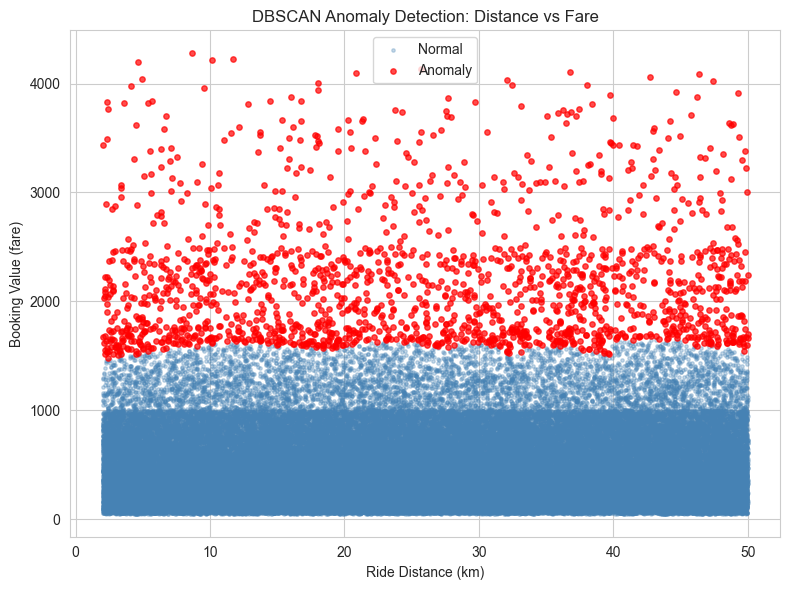

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
normal = cluster_df["DBSCAN_Label"] != -1
ax.scatter(cluster_df.loc[normal, "Ride Distance"], cluster_df.loc[normal, "Booking Value"],
           s=6, alpha=0.3, label="Normal", c="steelblue")
ax.scatter(cluster_df.loc[~normal, "Ride Distance"], cluster_df.loc[~normal, "Booking Value"],
           s=15, alpha=0.7, label="Anomaly", c="red")
ax.set_xlabel("Ride Distance (km)")
ax.set_ylabel("Booking Value (fare)")
ax.set_title("DBSCAN Anomaly Detection: Distance vs Fare")
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
# Inspect a few flagged anomalies
cluster_df.loc[~normal, ["Vehicle Type", "Ride Distance", "Booking Value", "Payment Method"]] \
    .sort_values("Booking Value", ascending=False).head(10)

,Vehicle Type,Ride Distance,Booking Value,Payment Method
7450,Go Mini,8.66,4277.0,UPI
83506,Bike,11.73,4228.0,Debit Card
2731,Auto,10.11,4220.0,UPI
90418,Auto,4.62,4202.0,Uber Wallet
7116,Go Mini,25.66,4133.0,Cash
43469,Go Mini,36.81,4109.0,UPI
21011,eBike,20.85,4093.0,UPI
32935,Go Sedan,46.36,4088.0,UPI
117985,Auto,42.72,4060.0,Cash
90667,Go Sedan,4.97,4044.0,UPI


## 8. Summary

- **Classification** (Random Forest): predicts whether a booking completes, from
  pre-ride info only — check the ROC-AUC and confusion matrix above for how well it
  separates cancelled/no-driver-found bookings from completed ones.
- **Regression** (Random Forest): predicts fare for completed rides from trip
  characteristics, evaluated with MAE/RMSE/R² against a linear baseline.
- **KMeans + PCA**: unsupervised segmentation of completed rides into behavioral groups
  (e.g. short/cheap vs. long/premium vs. low-rated-slow-pickup), chosen via elbow +
  silhouette, visualized in 2D via PCA, and profiled by mean feature values and vehicle mix.
- **DBSCAN**: density-based anomaly detection on the fare-vs-distance relationship,
  flagging rides worth a manual look.

**Natural extensions if you want to push further:**
- Tune `eps`/`min_samples` in DBSCAN with a k-distance plot instead of guessing.
- Try hierarchical clustering (`AgglomerativeClustering`) and compare cluster structure
  to KMeans via a dendrogram.
- Add `GridSearchCV`/`RandomizedSearchCV` for hyperparameter tuning on both supervised models.
- Engineer pickup/drop **location pair** as a feature (route-level demand patterns) — bin
  by NCR sub-region instead of raw locality name to avoid extreme cardinality.
- Use SHAP values instead of plain feature importances for the classifier for a more
  rigorous, per-prediction explanation.

In [31]:
normal = cluster_df[cluster_df["DBSCAN_Label"] != -1]

In [32]:
normal.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Datetime,Hour,DayOfWeek,Month,IsWeekend,Cluster,DBSCAN_Label
2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday,8,False,4,0
3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday,10,False,2,0
4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday,9,False,6,0
5,2024-02-06,09:44:56,CNR4096693,Completed,CID4670564,Auto,AIIMS,Narsinghpur,5.1,18.1,NaN,NaN,NaN,NaN,NaN,NaN,316.0,4.85,4.1,4.6,UPI,2024-02-06 09:44:56,9,Tuesday,2,False,4,0
6,2024-06-17,15:45:58,CNR2002539,Completed,CID6800553,Go Mini,Vaishali,Punjabi Bagh,7.1,20.4,NaN,NaN,NaN,NaN,NaN,NaN,640.0,41.24,4.0,4.1,UPI,2024-06-17 15:45:58,15,Monday,6,False,6,0


In [33]:

import xgboost as xgb
reg_df = normal.dropna(subset=["Booking Value", "Ride Distance", "Avg VTAT", "Avg CTAT","Driver Ratings","Customer Rating"]).copy()

reg_features_num = ["Ride Distance", "Avg VTAT", "Avg CTAT", "Hour","Driver Ratings","Customer Rating"]
reg_features_cat = ["Vehicle Type", "Payment Method", "IsWeekend"]

X_reg = reg_df[reg_features_num + reg_features_cat]
y_reg = reg_df["Booking Value"]

reg_preprocess = ColumnTransformer([
    ("num", StandardScaler(), reg_features_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), reg_features_cat),
])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

reg_pipeline = Pipeline([
    ("prep", reg_preprocess),
    ("model", xgb.XGBRegressor(n_estimators=500,learning_rate=0.1,max_depth=2,objective="reg:squarederror",random_state=42
))])
reg_pipeline.fit(Xr_train, yr_train)

yr_pred = reg_pipeline.predict(Xr_test)
print("MAE :", round(mean_absolute_error(yr_test, yr_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(yr_test, yr_pred)), 2))
print("R^2 :", round(r2_score(yr_test, yr_pred), 4))

MAE : 245.41
RMSE: 307.4
R^2 : 0.0606


In [34]:
# Simple linear baseline for comparison — shows how much the RF is buying you
lin_pipeline = Pipeline([("prep", reg_preprocess), ("model", LinearRegression())])
lin_pipeline.fit(Xr_train, yr_train)
yr_pred_lin = lin_pipeline.predict(Xr_test)
print("Linear Regression R^2 :", round(r2_score(yr_test, yr_pred_lin), 4))
print("XGB Regressor R^2     :", round(r2_score(yr_test, yr_pred), 4))

Linear Regression R^2 : 0.0632
XGB Regressor R^2     : 0.0606
